In [2]:
import numpy
import AILibs

dt = 1.0/250.0

num_samples = 1000
        

#  system dynamics
#  state = [x, x_dot, theta, theta_dot]
A = [   [   1.0,    0.004,      0.0,    0.0     ],
        [   0.0,    0.826234,   0.0,    0.0     ],
        [   0.0,    0.0,        1.0,    0.004   ],
        [   0.0,    0.0,        0.0,    0.825308]]

B = [   [ 0.0,          0.0      ],
        [ 0.492847,     0.0      ],
        [ 0.0,          0.0      ],
        [ 0.0,          10.918607]]

A = numpy.array(A)  
B = numpy.array(B)

A = numpy.array(A)
B = numpy.array(B)

system_order      = A.shape[0]
system_inputs     = B.shape[1]
prediction_horizon = 32
control_horizon    = 8

Q = numpy.diag([1.0, 0.0, 1.0, 0.0])
R = numpy.diag([0.01, 1.0])  


controller = AILibs.MPCAnalytical(A, B, Q, R, prediction_horizon=prediction_horizon, control_horizon=control_horizon, u_max=10**10, du_max=0.2)


def save_mpc_header(file_path, controller, system_order, system_inputs, prediction_horizon, control_horizon):
    """
    Save MPC controller matrices (Phi, Theta, Sigma) as a C header file.
    Matrices are stored as 1D arrays with rows preserved for readability.
    """
    def matrix_to_c_array(name, mat):
        mat = numpy.atleast_2d(mat)
        rows, cols = mat.shape
        lines = []
        lines.append(f"const float mpc_{name}[] = {{")
        for i in range(rows):
            row_str = ", ".join(f"{round(mat[i, j], 5)}" for j in range(cols))
            comma = "," if i < rows - 1 else ""
            lines.append(f"\t\t{row_str}{comma}")
        lines.append("};")
        lines.append("")
        return "\n".join(lines)

    header  = "#ifndef _MPC_CONFIG_H_\n"
    header += "#define _MPC_CONFIG_H_\n"
    header += "\n\n\n"
    header += f"#define MPC_SYSTEM_ORDER      ((uint32_t){system_order})\n"
    header += f"#define MPC_SYSTEM_INPUTS     ((uint32_t){system_inputs})\n"
    header += f"#define MPC_PREDCTION_HORIZON ((uint32_t){prediction_horizon})\n"
    header += f"#define MPC_CONTROL_HORIZON   ((uint32_t){control_horizon})\n"
    header += "\n\n\n"
    header += matrix_to_c_array("phi", controller.Phi)
    header += "\n"
    header += matrix_to_c_array("omega", controller.Omega)
    header += "\n"
    header += matrix_to_c_array("sigma", controller.Sigma0)
    header += "\n\n"    
    header += "#endif\n"

    with open(file_path, "w") as f:
        f.write(header)

    print(f"MPC header saved to: {file_path}")
    print(f"  Phi   shape: {controller.Phi.shape}")
    print(f"  Omega shape: {controller.Omega.shape}")
    print(f"  Sigma shape: {controller.Sigma.shape}")


# save to firmware header
save_mpc_header("mpc_config.h", controller, system_order, system_inputs, prediction_horizon, control_horizon)

MPC header saved to: mpc_config.h
  Phi   shape: (128, 4)
  Omega shape: (128, 2)
  Sigma shape: (16, 128)


In [3]:
ds = AILibs.DynamicalSystemDiscrete(A, B, None)


x = ds.reset()

# 1m distance
d = 1.0

# 90 degrees
a = 90*numpy.pi/180.0

# desired states
xr_a = numpy.array([0.0, 0.0, 0.0, 0.0])
xr_b = numpy.array([d, 0.0, 0.0, 0.0])
xr_c = numpy.array([0.0, 0.0, a, 0.0])
xr_d = numpy.array([d, 0.0, a, 0.0])

# time step
t_result = []

# control inputs
u_result = []

# desired states
xr_result = []

# actual states
x_result = []

u = numpy.zeros((B.shape[1], 1))

for n in range(num_samples):

    # add zero state between different reference states
    
    if n < num_samples/5:
        xr = xr_a
    elif n < 2*num_samples/5:
        xr = xr_b
    elif n < 3*num_samples/5:
        xr = xr_a
    elif n < 4*num_samples/5:
        xr = xr_c
    else:
        xr = xr_d

    xr = numpy.expand_dims(xr, axis=1)


    u = controller.forward(xr, x, u)
    
    x, _ = ds.forward_state(u)

    t_result.append(n*dt)
    u_result.append(u)
    xr_result.append(xr)
    x_result.append(x)


t_result = numpy.array(t_result)
u_result = numpy.array(u_result)
xr_result = numpy.array(xr_result)
x_result = numpy.array(x_result)

print("done")

done


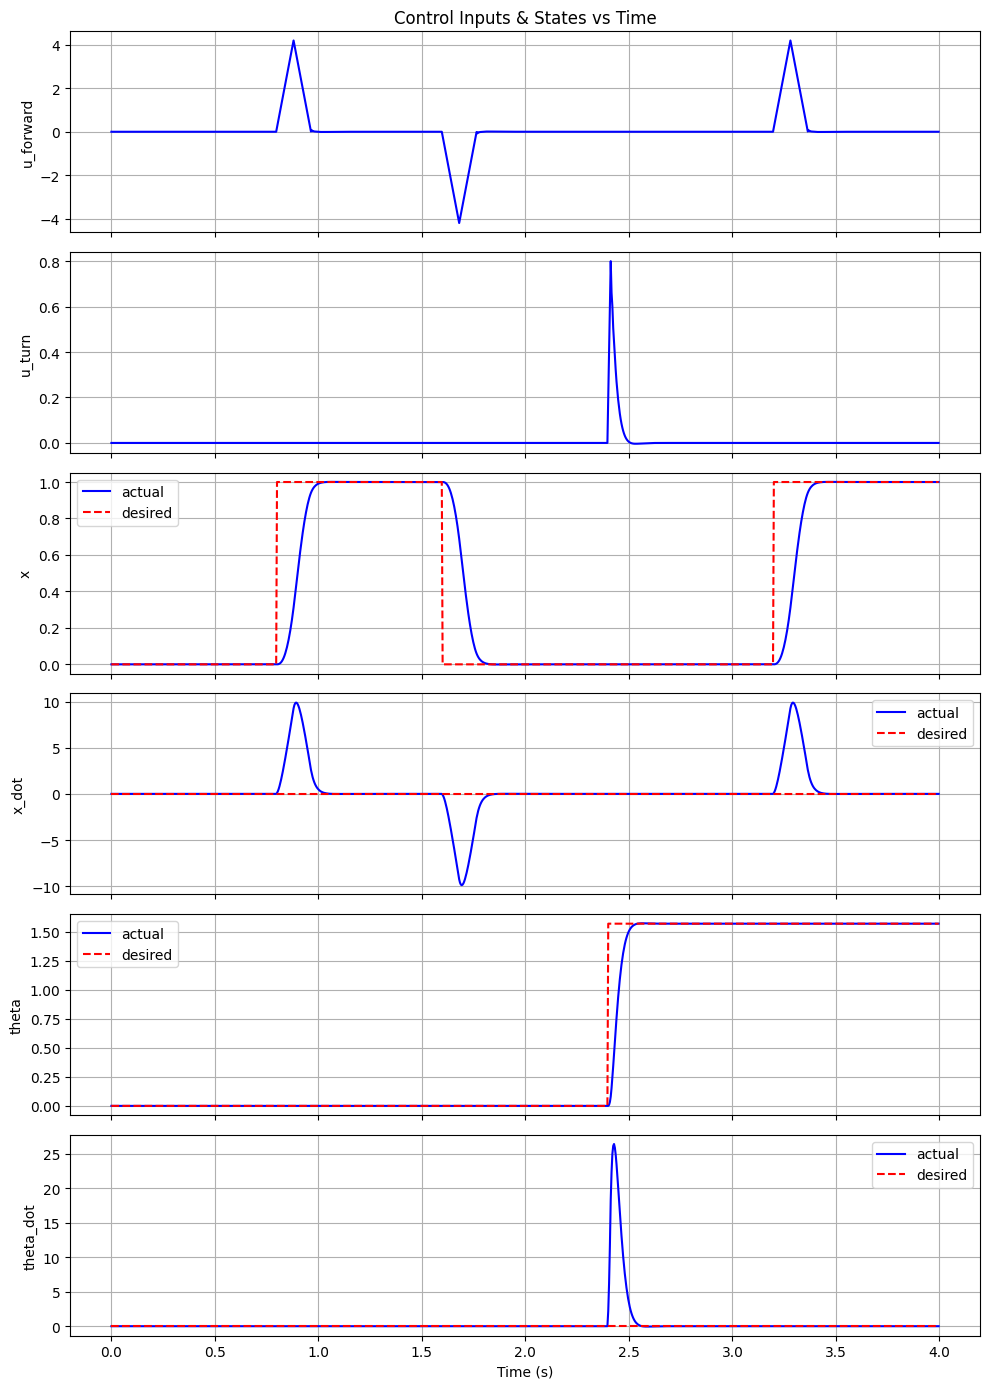

In [4]:
import matplotlib.pyplot as plt

control_labels  = ['u_forward', 'u_turn']
state_labels    = ['x', 'x_dot', 'theta', 'theta_dot']

fig, axes = plt.subplots(6, 1, figsize=(10, 14), sharex=True)

for i in range(2):
    axes[i].plot(t_result, u_result[:, i, 0], color='blue')
    axes[i].set_ylabel(control_labels[i])
    axes[i].grid()

for i in range(4):
    axes[i+2].plot(t_result, x_result[:, i], color='blue', label='actual')
    axes[i+2].plot(t_result, xr_result[:, i, 0], color='red', linestyle='dashed', label='desired')
    axes[i+2].set_ylabel(state_labels[i])
    axes[i+2].legend()
    axes[i+2].grid()

axes[-1].set_xlabel('Time (s)')
axes[0].set_title('Control Inputs & States vs Time')
plt.tight_layout()
plt.show()